# Conversão de dados para pulsos

Os dados gerados pela fonte e codificados tem valores discretos em um determinado conjunto finito $\{x_1, ..., x_M\}$, e precisam ser transformados em um sinal analógico para serem transmitidos. Um primeiro passo nesse sentido é associar cada valor $x_i$  um pulso de duração $T$, que poderá em seguida ser modulado.

Tanto o formato do pulso, quanto a forma de codificar são importantes para contolar o espectro do sinal, conforme descrito a seguir.

Ver: https://wiki.sj.ifsc.edu.br/images/1/1a/Codificacao_LinhaV2.pdf


## Pulsos RZ (Return to Zero)

O **RZ (Return to Zero)** é um formato de codificação em que cada bit é representado por um nível lógico, mas o sinal sempre retorna a zero antes do final do período de bit:
- O **bit 1** é representado por um pulso positivo durante metade do tempo de bit e depois retorna a zero.
- O **bit 0** pode ser representado por ausência de pulso ou por um pulso negativo, dependendo da variação do esquema.

Isso significa que o sinal ocupa mais largura de banda, mas facilita a **sincronização**, pois o retorno a zero fornece uma referência de tempo.


## Pulsos NRZ (Non-Return to Zero)

O **NRZ (Non-Return to Zero)** é um formato em que o sinal **não retorna a zero** no meio do intervalo de bit. Ele pode ser de dois tipos principais:

- **NRZ-L (Level):** cada bit é representado diretamente por um nível de tensão constante (por exemplo, nível alto = 1, nível baixo = 0).
- **NRZ-I (Invert):** a transição de nível ocorre apenas quando há um bit **1**; o bit **0** mantém o nível anterior.

O NRZ é mais eficiente em termos de largura de banda, mas pode sofrer problemas de **sincronização** em longas sequências de 0s ou 1s, já que não há transições suficientes para manter o relógio alinhado.



## Outros tipos de codificação de linha

### **Manchester**

Cada bit é representado por **duas transições** dentro do período de bit.

- O *bit 0* pode ser representado por uma transição alto para baixo.
* O *bit 0* pode ser representado por uma transição baixo para alto.


### **AMI (Alternate Mark Inversion)**

Os bits **0** são enviados como ausência de pulso, enquanto os **1s** alternam entre pulsos positivos e negativos.

Isso ajuda a reduzir a componente DC e facilita a detecção de erros.

### **HDB3 (High Density Bipolar-3)**

É uma evolução do AMI, usada em telecomunicações, que insere violações controladas na sequência para evitar longos períodos sem transições.

Garante sincronização sem aumentar muito a largura de banda.

### **PWM (Pulse Width Modulation)**

A informação é codificada pela **largura do pulso** dentro do intervalo de bit.

Usado em controles digitais e sistemas de potência.

O formato do pulso usado para representar o valor de saída dos codificadores influencia diretamente a largura de banda ocupada. Por exemplo, consideremos um pulso quadrado, dado por
$$\Pi\left(\frac{t}{T}\right) = \left\{\begin{array}{cc}
1     &  -T/2 \leq t \leq T/2\\
0     &  c.c
\end{array}\right.
$$
cujas amplitudes serão alterados pelos valores $x_i$. Aplicando a transformada de Fourier obtemos
$$
\Pi(f) = T.sinc(fT),
$$
que como sabemos tem largura de banda infinita.

Nesse momento, como estamos preocupados somente com a ocupação espectral, podemos utilizar um formato para $p(t)$ que seja mais compacto no tempo. Um exemplo é dado por
$$
cl(t) = \frac{A}{2}\left(1 + \cos\frac{\pi t}{\tau}\right)\Pi\left(\frac{t}{2\tau}\right)
$$
cuja tranformada de Fourier é dada por
$$
CL(f) = \frac{A\tau.sinc(2f\tau)}{1 - (2f\tau)^2}
$$
e está representado na Figura abaixo.

FIGURA

Observe que o cosseno levantado é função limitada do tempo, e aproximadamente limitada da frequência, visto que a potência cai com o qauadrado da frequência.

Nesse momento, como estamos preocupados somente com a ocupação espectral, podemos utilizar um formato para $p(t)$ que seja mais compacto no tempo. Um exemplo é dado por
$$
cl(t) = \frac{A}{2}\left(1 + \cos\frac{\pi t}{\tau}\right)\Pi\left(\frac{t}{2\tau}\right)
$$
cuja tranformada de Fourier é dada por
$$
CL(f) = \frac{A\tau.sinc(2f\tau)}{1 - (2f\tau)^2}
$$
e está representado na Figura abaixo.

FIGURA

Observe que o cosseno levantado é função limitada do tempo, e aproximadamente limitada da frequência, visto que a potência cai com o qauadrado da frequência.

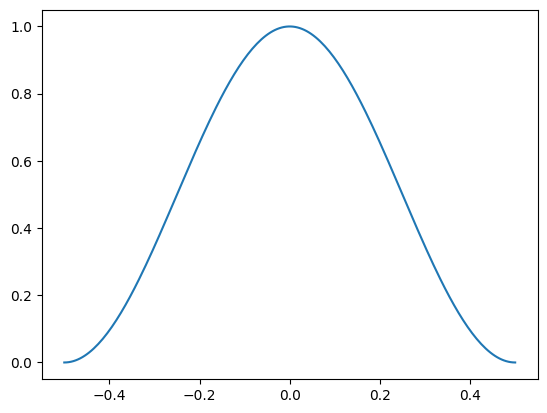

In [6]:
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

A = 1
tau = 0.5
t = np.linspace(-0.5,0.5, 200)
cl = (A/2)*(1+np.cos(np.pi*t/tau))
plt.plot(t, cl)

# Modulação Digital



### M-ASK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = I_kp_T(t)\cos(\omega_c t).
$$

Vamos iniciar considerando que os dados estão representados em binário $\{0,\ 1\}$sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de amplitudes, dai o nome *On-Off Keying - OOK*, 
como representado na figura abaixo (Você pode obter esse gráfico usando o diagrama ASK.grc disponivel na pasta Demonstrações).

![asktconstelacao](./Figuras/OOK.png)

Neste ponto, podemos definir um diagrama para representar a fase e a quadratura que represente as possibilidades do sinal. No caso do ASK o diagrama tem dois pontos, um em zero e outro no eixo real na posição $I_k.$ 

![asktconstelacao](./Figuras/Constelacao_OOK.png)

O espectro do sinal $ASK$ será definido pelo espectro do pulso $p_t(t)$, sendo assim, para um pulso quadrado com frequência de $100 Hz$ cujo espectro é representado na figura abaixo,

![asktconstelacao](./Figuras/Espectro_Pulso.png)

o espectro do sinal OOK consiste no deslocamento pra a frequência da portadora, no exemplo abaixo considere $f_c = 1\ KHz$.

![asktconstelacao](./Figuras/Espectro_OOK.png)

A demodulação de um sinal OOK poder ser feita usando a Detecção Coerente, ou seja, um demodulador de envotória.

Se considerarmos um sinal $M$-ASK, ($M >2$) as análises acima continuam válidas.

### M-FSK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, são aplicados a um modulador em Frequência (FM). que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = \cos[\omega_c t + K_f\int_{-\infty}^{t}I_kp_T(\alpha)d\alpha)].
$$

Sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de frequências, dai o nome *Frequency-Shift Keying - FSK*, 
como representado na figura abaixo.

FIGURA

Um sinal FSK tem duas frequências para um pulso NRZ (*Non Return to Zero*) que tem média zero e amplitudes $m_p$ e $-m_p$ tem as frequências
$$
\omega_{min} = \omega_c - k_f m_p\ e\ \omega_{max} = \omega_c + k_f m_p.
$$
e pode ser escrito como
$s(t) = \left\{\begin{array}{c c} 
\cos(\omega_{min} t) & bit\ 0\\ 
\cos(\omega_{max} t) & bit\ 1
\end{array}\right.$


Neste ponto, como a amplitude é consente, o diagrama de constelação terá apenas um ponto.

FIGURA

Lembremos que na modulação em FM, quando a frequência instantânea é $\omega_i$, naquela posição do espectro está ocupada a largura de banda da mensagem. No caso do sinal $FSK$ com um pulso quadro haverão duas sincs, uma em cada frequência, logo a largura de banda ocupada continua sendo 
$B_{FM} = 2(B_M + k_fm_p).$

FIGURA

É comum usar FSK com um pulso NRZ para evitar o impulso.

### M-PSK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, são aplicados a um modulador em Fase (PM). que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = \cos[\omega_c t + K_pI_kp_T(\alpha))].
$$
Logo, a cada valor de $I_k$ associa-se uma fase.E ajustando a codificação dos símbolos, é possível obter um conjunto de fases
$$
\Phi_k \in \{\pm\frac{\pi}{M}, \pm\frac{3\pi}{M}, ..., \pm\frac{(M-1)\pi}{M}\}
$$

Sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de Fases, dai o nome *Phase-Shift Keying - FSK*, 
como representado na figura abaixo.

Figura

Um sinal 2-PSK tem duas fases para um pulso NRZ (*Non Return to Zero*) que tem média zero e amplitudes $m_p$ e $-m_p$ tem as frequências
$$
\omega_{min} = \omega_c - k_f m_p\ e\ \omega_{max} = \omega_c + k_f m_p.
$$
e pode ser escrito como
$s(t) = \left\{\begin{array}{c c} 
\cos(\omega_{c} t - \frac{\pi}{2}) & bit\ 0\\ 
\cos(\omega_{c} t + \frac{\pi}{2})& bit\ 1
\end{array}\right.$


Podemos agora desenhar o diagrama de constelação, para $M = 4$ temos

![psktconstelacao](./Figuras/pskconstelacao.png)


A partir deste ponto vamos considerar que  o modulador recebe a sequência de bits a ser transmitida e que pode simultanemante utilizar um cosseno e um seno na mesma frequência, o que vai gerar as modulações em quadratura, conforme descrito a seguir. 

## Modulação $M$-ária em quadratura

Vamos considerar a representação genérica de um sinal modulado como
$$
s(t) = s_i(t - kT) - s_q(t - kT)
$$
sendo
$$
s_i(t) = A_cI_kp_T(t)\cos(\omega_c t) \ \ e \ \ s_q(t) = s(t) = A_c Q_kp_T(t)\sin(\omega_c t)
$$
com $A_c$ a amplitide que é função da potência de transmissão, $I_k\ e\ Q_k \in \{ -M, -M+1, ..., M-1, M\}$ e $p_T(t)$ um pulso com duração de $T$ instantes de tempo.

Para $M = 2$ e $I_k\ e\ Q_k \in \{-1, +1\}$, para representar os possíveis valores temos que usar dois eixos ortigonais, um para a fase outro para quadratura, como mostrado na figura abaixo. Neste caso temos a Modulação em Quadratura de Amplitude (QAM - *Quadrature Amplitude Modulation*).

![mskconstelacao](./Figuras/mskconstelacao.png)

## Modulação PSK $M$-ária

Outra forma de relizar a modução é fazendo
$$
s(t) = s_i(t - kT) - s_q(t - kT)
$$
sendo
$$
s_i(t) = A_c \cos\phi_k\cos(\omega_c t) \ \ e \ \ s_q(t) = A_c \sin\phi_k sin(\omega_c t)
$$

com $A_c$ a amplitide que é função da potência de transmissão, $\phi_k$ um ângulo que é função da informação.

O digrama de constelação de uma modulação PSK consiste de um círculo, com raio $A_c$ e os pontos localizados nos ângulos $\pi/M$. Na figura abaixo tem-se a representação para $M = 4$.

![psktconstelacao](./Figuras/pskconstelacao.png)

## Desempenho das modulações digitais

Para avaliar o desempenho de modulações digitais se analisa a **Probabilidade de erro de Bit** ou a **eficiência espectral**. A primeira medida, considera que o sinal modulado será transmitido pode um canal com ruído que podem causar erros na recepção. A segunda, indica quanto bits por segundo por Hertz podem ser transmitidos.

Considerando inicialmente a Probabilidade de erro de Bit, vamos considerar que ao sinal modulado é adicionado um sinal aleatório com distribuição de probabilidades Gaussiana com média zero e variância $\sigma^2$, ou seja,
$$n(t) \sim \mathcal{N}(0, \sigma^2).$$

Sendo o sinal recebido $$r(t) = s(t) + n(t)$$ com $s(t)$ um sinal produzido por um modulador digital, como $n(t)$ é uma variável aleatória, se desenharmos o diagrama de constelação para $r(t)$ vermos que cada ponto da constelação de $s(t)$ foi acrescrido de um valor guassino, portanto pode ter sido deslocado para qualquer ponto do plano cartesino ao entonro do ponto original.

Como exemplo, considere o sinal $OOK$ ($M = 2$ e $I_k = \{0, 1\}$), cuja constelação está mostrada na figura acima. Ao adicionar o ruído Gaussiano, como representado na fiura abaixo, o ponto da constelação na recepção (considerando a sincronização entre transmissor e receptor) pode estar em qualquer valor no eixo da abscissas (a variação de ponto referente a $I_k = 1$ não está representada) de acorda com a distribuição $\mathcal{N}(0, \sigma^2)$.


![OOK_ruido](./Figuras/OOK_Ruido.png)

Caso o receptor use a deteccão baseada em um limiar para definir o bit $b_k$, por exemplo, sendo $I_r$ o valor recebido:
$$
b_k = \left\{\begin{array}{c c} 0_2 & I_r \leq 0,5 \\ 1_2 & I_r > 0,5 \end{array} \right.$$
então dependendo do valor do ruído, um bit $0$ pode ser decidificado como $1$, causando assim um **erro de bit**. 

Se fizermos a razão entre a quantidade de bits demodulados de forma errada pelo total de bits transmitidos, termos a **Probabilidade de Erro de Bit** ($P_b$), que é uma das medidas de desempenho dos sistema de modulação digital.

Para uma mesma modulação, quanto maior for a variância do ruído, $\sigma^2$, maior será a $P_b$. Considerando que sinal transmitido tem uma potência $P_s$, e que a potência do ruído Gaussiano é $P_n = \sigma^2$, define-se a **Relação Sinal Ruído** (SNR - *Signal to Noise Ratio*) como $$SNR = P_s/P_n$$ e que normalmente é representada na escala logarítimica $$SNR_dB = 10log_{10}\left(\frac{P_s}{P_n}\right) = 10log_{10}\left(\frac{P_s}{\sigma^2}\right).$$
Os gráficos de desempenho são desenhados usando $SNR_{dB} \times P_b.$

Como exemplo, voltemos ao sinal OOK
$$
s(t) = I_kp_T(t)\cos(\omega_c t)
$$
e para facilitar a representação vamos escrever para a transmisão do bit 1:
$$
s_1(t) = \sqrt{E_s} \, \varphi(t)
$$
sendo $\sqrt{E_s}$ a energia por símbolo, e $\varphi(t) = p_T(t)\cos(\omega_c t)$, para o bit 0:
$$s_0(t) = 0.$$

No receptor, vamos usar um filtro casado, que consiste em um comparador do pulso $p_r(t)$ recebido com os pulsos conhecidos (neste caso $p_T(t)$ para o bit 1 e 0 (zero) para o bit 0) dada por
$$
x = \langle r, \varphi \rangle = \int_{t}^{t+T}s(t)p_T(t + \tau)d\tau$$
que no caso do sinal recebido com ruído
$$
x = \langle r, \varphi \rangle = \langle s_i, \varphi \rangle + \langle n, \varphi \rangle
$$
logo temos duas hipóteses: $H_1$ que o bit 1 foi transmitido e $H_0$ que o bit 0 foi transmitido, ou seja,
$$
x \mid H_1 \sim \mathcal N(\mu_1=\sqrt{E_s}, \, \sigma^2=N_0/2), 
\qquad
x \mid H_0 \sim \mathcal N(\mu_0=0, \, \sigma^2=N_0/2)
$$

O limiar de decisão ótimo é o ponto médio:
$$
y = \frac{\mu_0 + \mu_1}{2} = \frac{\sqrt{E_s}}{2}
$$
Sendo assim:
- Se $x > y \Rightarrow$ decide "1"
- Caso contrário decide "0"

![psktconstelacao](./Figuras/OOK_ruido_Limiar.png)

Erro quando o bit 1 foi transmitido ($H_1$):

$$
P(e \mid H_1) = \int_{-\infty}^{\gamma} 
\frac{1}{\sqrt{2 \pi \sigma^2}} 
\exp\!\left(-\frac{(y-\mu_1)^2}{2\sigma^2}\right) dy
$$
então:
$$
P(e \mid H_1) 
= Q\!\left(\frac{\sqrt{E_s} - \sqrt{E_s}/2}{\sqrt{N_0/2}}\right)
= Q\!\left(\frac{\sqrt{E_s}}{\sqrt{2N_0}}\right)
$$

Erro quando o bit 0 foi transmitido ($H_0$):
$$
P(e \mid H_0) = \int_{\gamma}^{\infty}
\frac{1}{\sqrt{2 \pi \sigma^2}}
\exp\!\left(-\frac{(y-\mu_0)^2}{2\sigma^2}\right) dy
$$
então:
$$
P(e \mid H_0) 
= Q\!\left(\frac{\sqrt{E_s}/2 - 0}{\sqrt{N_0/2}}\right)
= Q\!\left(\frac{\sqrt{E_s}}{\sqrt{2N_0}}\right)
$$

Assumindo bits equiprováveis ($P(H_0)=P(H_1)=1/2$)
$$P_b = \tfrac{1}{2} P(e\mid H_1) + \tfrac{1}{2} P(e\mid H_0)
= Q\!\left(\frac{\sqrt{E_s}}{\sqrt{2N_0}}\right)
$$

Como em OOK apenas metade dos bits transmite energia:
$$
E_b = \tfrac{1}{2} E_s \quad \Rightarrow \quad E_s = 2E_b
$$
então:
$$
\boxed{\, P_b = Q\!\left(\sqrt{\frac{E_b}{N_0}} \right) \,}
$$
e $SNR_dB = 10log_{10}\left(\frac{E_b}{N_0}\right).$

Se $E_b$ for definido como a energia quando o bit 1 é enviado (em vez de energia média por bit), então a expressão fica:
$$P_b = Q\!\left(\sqrt{\frac{E_b}{2N_0}}\right).
$$

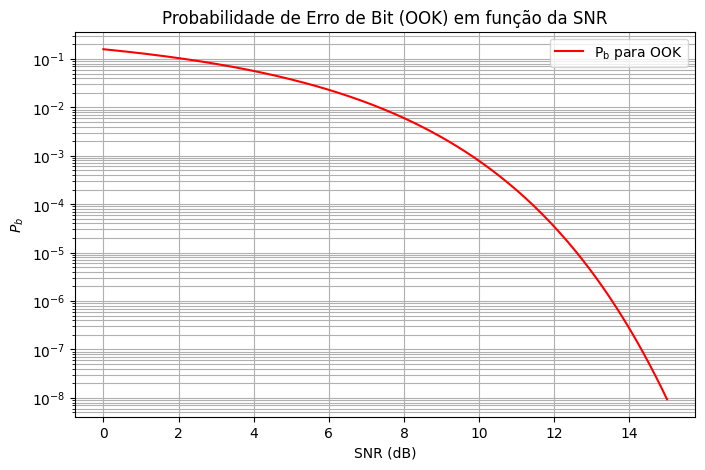

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Definição da função Q(x)
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2))

# Intervalo de SNR em dB
snr_db = np.linspace(0, 15, 200)   # de 0 a 15 dB

# Conversão para escala linear
snr_linear = 10**(snr_db / 10)

# Cálculo da probabilidade de erro
pb = Q(np.sqrt(snr_linear))

# Plotando
plt.figure(figsize=(8,5))
plt.semilogy(snr_db, pb, label=r'$\mathrm{P_b}$ para OOK', color='red')
plt.title("Probabilidade de Erro de Bit (OOK) em função da SNR")
plt.xlabel("SNR (dB)")
plt.ylabel(r"$P_b$")
plt.grid(True, which="both")
plt.legend()
plt.show()


## Diagrama de Olho (*Eye Diagram*)

Considere que um osciloscópio desenha o sinal recebido porém com a caracterísitica de que a cada $nT$ segundo o traço é fereito sem apagar o anterior. O diagrama desenhado mostrado desenhará a sequência de pulsos sobreposto a emdida que o tempo passa, e esse diagrama é conhecido como Digrama de Olho (*Eye Diagram*).

No caso ideal (sem ruído e outros erros) não haverá sobreposição de pulsos com amplitudes distintas.

Veja a demonstração em Diagrama/eye_diagram_simplified.grc